<h2>ЛР 2 Проведение экспериментов по настройке модели

In [265]:
import os

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

import matplotlib.pyplot as plt

<h3>Разбиваем выборку

In [266]:
df = pd.read_pickle('../data/clean_data.pkl')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Major_Category              50000 non-null  category
 1   Year_of_Study               50000 non-null  category
 2   Pre_Semester_GPA            50000 non-null  float32 
 3   Weekly_GenAI_Hours          50000 non-null  float32 
 4   Primary_Use_Case            50000 non-null  category
 5   Prompt_Engineering_Skill    50000 non-null  category
 6   Tool_Diversity              50000 non-null  int8    
 7   Paid_Subscription           50000 non-null  bool    
 8   Traditional_Study_Hours     50000 non-null  float32 
 9   Perceived_AI_Dependency     50000 non-null  int8    
 10  Institutional_Policy        50000 non-null  category
 11  Anxiety_Level_During_Exams  50000 non-null  int8    
 12  Post_Semester_GPA           50000 non-null  float32 
 13  Skill_Retention_

In [267]:
features = [
    'Pre_Semester_GPA', 
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Perceived_AI_Dependency',
    'Institutional_Policy',
    'Anxiety_Level_During_Exams',
    ]
target = 'Post_Semester_GPA'
X = df[features]
y = df[target]

In [268]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [269]:
X_train.iloc[0]

Pre_Semester_GPA                              3.786
Weekly_GenAI_Hours                            12.59
Traditional_Study_Hours                        6.71
Perceived_AI_Dependency                           3
Institutional_Policy          Allowed_With_Citation
Anxiety_Level_During_Exams                        2
Name: 39087, dtype: object

In [270]:
cat_features = X_train.select_dtypes(include=['category','object']).columns.to_list()
cat_features

['Institutional_Policy']

In [271]:
num_features = X_train.select_dtypes(include=['number']).columns.to_list()
num_features

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams']

In [272]:
s_scaler = StandardScaler()
l_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=99999999) # unknown_value нужно выбирать с умом
regressor = CatBoostRegressor()

In [273]:
# Для удобной работы со столбцами
preprocessor = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
    ],
    remainder='drop' ) # Удаляем столбцы, которые не затронуты преобразования

In [274]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                           ('model', regressor)])

pipeline.fit(X_train, y_train)

Learning rate set to 0.073334
0:	learn: 0.4667155	total: 6.07ms	remaining: 6.06s
1:	learn: 0.4396027	total: 11.1ms	remaining: 5.55s
2:	learn: 0.4141592	total: 16.5ms	remaining: 5.47s
3:	learn: 0.3912892	total: 20.1ms	remaining: 5.01s
4:	learn: 0.3697478	total: 23.2ms	remaining: 4.61s
5:	learn: 0.3512227	total: 26.2ms	remaining: 4.34s
6:	learn: 0.3331563	total: 29.4ms	remaining: 4.17s
7:	learn: 0.3170656	total: 32.5ms	remaining: 4.04s
8:	learn: 0.3019771	total: 36ms	remaining: 3.97s
9:	learn: 0.2884780	total: 39.3ms	remaining: 3.88s
10:	learn: 0.2761378	total: 42.5ms	remaining: 3.82s
11:	learn: 0.2650350	total: 45.7ms	remaining: 3.77s
12:	learn: 0.2548219	total: 49.5ms	remaining: 3.76s
13:	learn: 0.2457152	total: 52.8ms	remaining: 3.72s
14:	learn: 0.2373214	total: 57.2ms	remaining: 3.76s
15:	learn: 0.2300305	total: 61.4ms	remaining: 3.77s
16:	learn: 0.2232439	total: 65.1ms	remaining: 3.77s
17:	learn: 0.2171123	total: 68ms	remaining: 3.71s
18:	learn: 0.2118656	total: 71.6ms	remaining: 3.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](0,)",[]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Pre_Semester_GPA','Weekly_GenAI_Hours','Traditional_Study_Hours', 'Perceived_AI_Dependency','Institutional_Policy', 'Anxiety_Level_During_Exams']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (

In [275]:
model_params = {
            "Pre_Semester_GPA":3.4,
            "Weekly_GenAI_Hours":16,
            "Tool_Diversity":1,
            "Traditional_Study_Hours":8,
            "Perceived_AI_Dependency":2,
            'Anxiety_Level_During_Exams':2,
            "Post_Semester_GPA":3.6,
            "Skill_Retention_Score":95.0,
            'Prompt_Engineering_Skill':"Advanced",
            'Year_of_Study': 'Graduate',
            'Primary_Use_Case': 'Debugging/Troubleshooting',
            'Institutional_Policy': 'Strict_Ban',
            }
df_pred = pd.DataFrame(model_params, index=[0])

In [276]:
pipeline.predict(df_pred)

array([3.46826353])

In [277]:
predictions = pipeline.predict(X_test) 

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': 0.12933895585930527,
 'mape': 0.04051527222544104,
 'mse': 0.028445869862276582}

In [278]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')

RMSE: 0.17
R² Score: 0.88


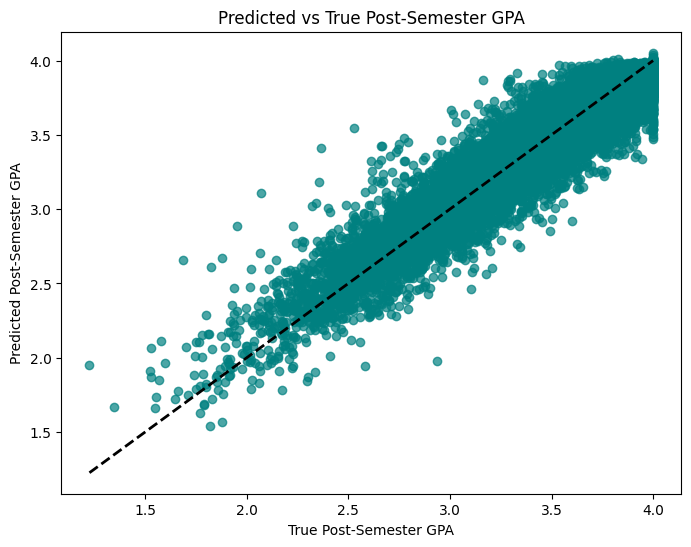

In [279]:
# Plot predictions vs true values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7, color='teal')
plt.xlabel('True Post-Semester GPA')
plt.ylabel('Predicted Post-Semester GPA')
plt.title('Predicted vs True Post-Semester GPA')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  
plt.show()

In [280]:
# Работаем с MLflow локально
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

registry_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
tracking_uri = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"

mlflow.set_tracking_uri(tracking_uri)   
mlflow.set_registry_uri(registry_uri)

NameError: name 'mlflow' is not defined